# House Price Prediction – Ames Housing Dataset

## Problem Statement
The goal of this project is to predict residential house sale prices using property characteristics from the Ames Housing dataset.

## Dataset Description
The dataset contains information about house size, quality, location, age, amenities, and other property attributes, along with the target variable **SalePrice**.

## Objective
1. Perform exploratory data analysis (EDA).
2. Clean and preprocess the data.
3. Train and compare multiple regression models.
4. Optimize the best-performing model using hyperparameter tuning.
5. Evaluate prediction error using MAE, RMSE, and R² score.


In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('AmesHousing.csv')
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [4]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [5]:
df.isnull().sum().sort_values(ascending=False).head(25)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Cond        159
Garage Finish      159
Garage Yr Blt      159
Garage Qual        159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
Garage Cars          1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
dtype: int64

In [6]:
df['SalePrice'].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

# Exploratory Data Analysis (EDA)

The purpose of EDA is to understand the target variable distribution, identify important predictors, and inspect relationships between features and sale price.

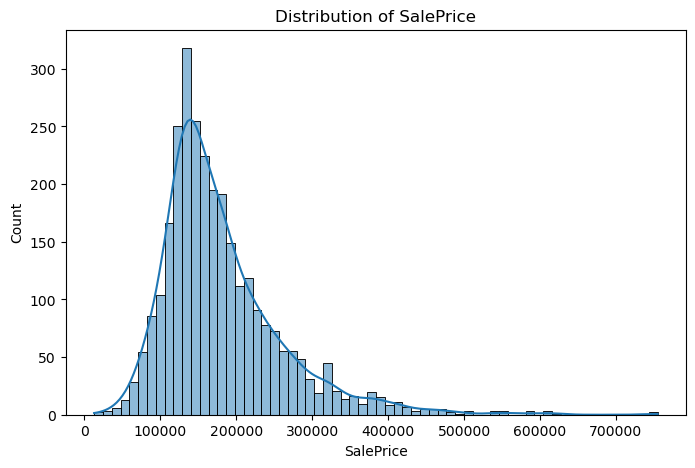

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], kde=True)
plt.title('Distribution of SalePrice')
plt.show()

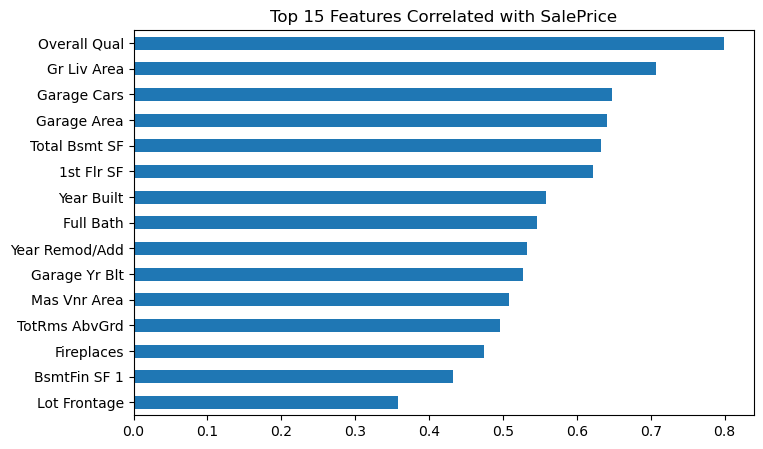

In [8]:
corr = df.corr(numeric_only=True)
top_corr = corr['SalePrice'].abs().sort_values(ascending=False)[1:16]

plt.figure(figsize=(8,5))
top_corr.sort_values().plot(kind='barh')
plt.title('Top 15 Features Correlated with SalePrice')
plt.show()

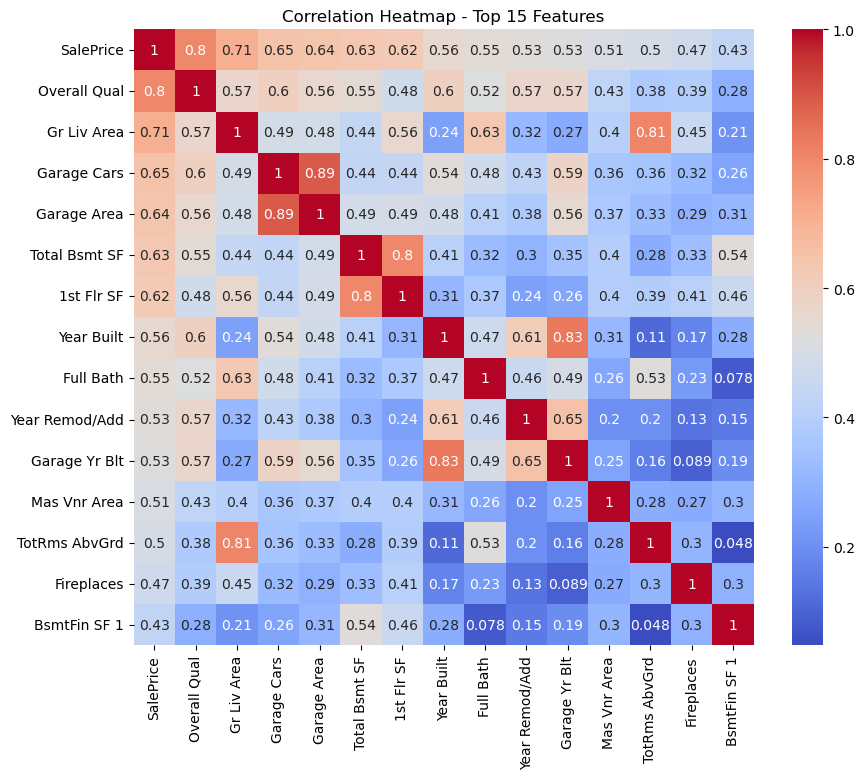

In [9]:
top_features = corr['SalePrice'].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(10,8))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap - Top 15 Features')
plt.show()

In [10]:
X=df.drop(['SalePrice','PID','Order'],axis=1)#pid or order hatadiye wo kyuki random the 
y=df['SalePrice']


In [11]:
numcol=X.select_dtypes(include=['int64','float64']).columns
catcol=X.select_dtypes(include=['object']).columns

In [12]:
corr=df.corr(numeric_only=True)
corr['SalePrice'].sort_values(ascending=False).head(15)

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432914
Name: SalePrice, dtype: float64

In [13]:
X.isnull().sum().sort_values(ascending=False).head(25)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Finish      159
Garage Yr Blt      159
Garage Cond        159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Half Bath       2
Bsmt Full Bath       2
Garage Area          1
Garage Cars          1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
dtype: int64

#missing value handling 

In [14]:
X[catcol] = X[catcol].fillna('None')

X[numcol] = X[numcol].fillna(X[numcol].median())

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


In [16]:
processor=ColumnTransformer(
    transformers=[('nums','passthrough',numcol),
                  ('cat',OneHotEncoder(handle_unknown='ignore'),catcol)
    ]
)

In [17]:
encoded_x=processor.fit_transform(X)

In [18]:
encoded_x.shape


(2930, 319)

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [20]:
X_train, X_test, y_train, y_test = train_test_split(encoded_x,y,
                                                                test_size=0.2,
                                                                            random_state=42
)

In [21]:
scaler = StandardScaler(with_mean=False)

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Baseline Model: Linear Regression

Linear Regression provides a simple benchmark model. It helps us understand how much predictive power can be achieved without regularization.

#using linear regression

In [22]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train,y_train)

pred = lr.predict(X_test)

In [23]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("R2:", r2_score(y_test,pred))

print("MAE:", mean_absolute_error(y_test,pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test,pred)))

R2: 0.8940085209097832
MAE: 15693.659431275117
RMSE: 29151.188035372077


# Ridge Regression

Ridge Regression is used because the dataset contains many encoded features. Regularization helps reduce overfitting and improves generalization by shrinking large coefficients.

using ridge regression

In [24]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1)

ridge.fit(X_train,y_train)

ridge_pred = ridge.predict(X_test)

In [25]:
print("R2:", r2_score(y_test,ridge_pred))

print("MAE:", mean_absolute_error(y_test,ridge_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test,ridge_pred)))

R2: 0.894786084783727
MAE: 15679.011253208759
RMSE: 29044.06321858107


# Lasso Regression

Lasso applies L1 regularization, which can drive some coefficients to zero and implicitly perform feature selection.

In [26]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1)

lasso.fit(X_train,y_train)

lasso_pred = lasso.predict(X_test)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:658: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 97784585965.90149, tolerance: 1393681263.833182
  model = cd_fast.sparse_enet_coordinate_descent(


In [27]:
print("R2:", r2_score(y_test,lasso_pred))

print("MAE:", mean_absolute_error(y_test,lasso_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test,lasso_pred)))

R2: 0.8946446456153783
MAE: 15683.692564276944
RMSE: 29063.57864332054


# Elastic Net

Elastic Net combines Ridge and Lasso penalties, balancing coefficient shrinkage and feature selection.

In [28]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha=1, l1_ratio=0.5)

elastic.fit(X_train,y_train)

elastic_pred = elastic.predict(X_test)

In [29]:
print("R2:", r2_score(y_test,elastic_pred))

print("MAE:", mean_absolute_error(y_test,elastic_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test,elastic_pred)))

R2: 0.8869573945546915
MAE: 16783.70437643867
RMSE: 30105.223921978322


# Hyperparameter Tuning with GridSearchCV

GridSearchCV systematically tests multiple values of the Ridge regularization parameter (`alpha`) using cross-validation. This helps identify the model configuration that performs best on unseen data rather than relying on a manually chosen value.

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

ridge = Ridge()

params = {
    'alpha':[0.001,0.01,0.1,1,10,100]
}

grid = GridSearchCV(
    ridge,
    params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [31]:
grid.best_params_
grid.best_score_

0.8598379678902702

In [32]:
best_ridge = grid.best_estimator_

pred = best_ridge.predict(X_test)

r2_score(y_test,pred)

0.8975040610888548

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("MAE:", mean_absolute_error(y_test,pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test,pred)))

MAE: 15542.138627103412
RMSE: 28666.463035113


In [34]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Elastic Net",
        "Tuned Ridge"
    ],
    
    "R2 Score": [
        0.8940,
        0.8948,
        0.8946,
        0.8870,
        0.8975
    ],
    
    "MAE": [
        15693,
        15679,
        15683,
        16783,
        15542
    ],
    
    "RMSE": [
        29151,
        29044,
        29063,
        30105,
        28666
    ]
})

results

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.8940,15693,29151
1,Ridge,0.8948,15679,29044
2,Lasso,0.8946,15683,29063
3,Elastic Net,0.8870,16783,30105
4,Tuned Ridge,0.8975,15542,28666


In [35]:
import pickle
pickle.dump(best_ridge, open("ridge_model.pkl","wb"))

In [36]:
import os
os.path.getsize("ridge_model.pkl")

2990

In [37]:
pickle.dump(processor, open("processor.pkl","wb"))
pickle.dump(scaler, open("scaler.pkl","wb"))

testing

In [38]:
model = pickle.load(open("ridge_model.pkl","rb"))
processor = pickle.load(open("processor.pkl","rb"))
scaler = pickle.load(open("scaler.pkl","rb"))

sample = X.iloc[0:1]
sample
sample_encoded = processor.transform(sample)
sample_scaled = scaler.transform(sample_encoded)
prediction = model.predict(sample_scaled)

prediction

array([222751.65954795])

In [39]:
print("Actual:", y.iloc[0])
print("Predicted:", prediction[0])

Actual: 215000
Predicted: 222751.65954794595


# Conclusion

After comparing Linear Regression, Ridge, Lasso, and Elastic Net models, the tuned Ridge Regression model achieved the strongest overall performance.

**Interpretation of MAE (~₹15,542):**
On average, the model's predicted house price differs from the actual sale price by approximately **₹15,542**. In practical terms, this means that for a typical property, the prediction error is relatively small compared with overall house values, making the model useful for estimating market prices.

Key takeaways:
- Proper preprocessing and encoding significantly improved model readiness.
- Ridge Regression handled the large number of features effectively.
- GridSearchCV helped select an optimal regularization strength.
- The final model provides a good balance between accuracy and generalization.
